# Two-loop (X–Z) fluxonium: spectrum, effective qubit Hamiltonian, and LZS leakage

Companion notebook to `two_loop_fluxonium_theory.pdf`. Section numbers below refer to that document.

The circuit is a fluxonium whose single small junction has been replaced by a **dc-SQUID**, giving
two loops and therefore two independently biasable fluxes:

- $\varphi_x$ — the **barrier** flux, threading the small SQUID loop. Tunes the tunnel splitting $\Delta$ (the $\sigma_x$ term).
- $\varphi_z$ — the **main-loop** flux. Tunes the well tilt $\epsilon$ (the $\sigma_z$ term).

The Hamiltonian (Eq. 12 of the PDF) is

$$\hat H(\varphi_z,\varphi_x) \;=\; 4E_C\hat n^2 \;+\; \tfrac12 E_L\hat\varphi^2 \;-\; E_J^{\rm eff}(\varphi_x)\,\cos\!\big(\hat\varphi-\varphi_z-\varphi_0(\varphi_x)\big)$$

with the dc-SQUID collapsed onto a single effective junction,

$$E_J^{\rm eff}(\varphi_x)=E_{J\Sigma}\sqrt{\cos^2\tfrac{\varphi_x}{2}+d^2\sin^2\tfrac{\varphi_x}{2}},
\qquad
\varphi_0(\varphi_x)=\operatorname{atan2}\!\Big(-d\sin\tfrac{\varphi_x}{2},\,\cos\tfrac{\varphi_x}{2}\Big),$$

where $E_{J\Sigma}=E_{J1}+E_{J2}$ and $d=(E_{J2}-E_{J1})/(E_{J1}+E_{J2})$ is the junction asymmetry.
This reduction is **exact**, not a small-$d$ expansion — Section 2 below re-verifies it numerically.

### What this notebook does differently from `fluxonium_lzs.ipynb`

| | old notebook | here |
|---|---|---|
| Fluxes | one ($\varphi_{\rm ext}$), so $\Delta$ not tunable | two ($\varphi_z,\varphi_x$) |
| Basis | harmonic (Fock) + `expm` on a dense $110^2$ matrix | discretised flux grid; $H$ is **tridiagonal** |
| $\epsilon$ | $\sqrt{\text{gap}^2-\Delta^2}$ — circular, cannot fail | persistent-current matrix element; hyperbola becomes a *testable prediction* |
| Convergence | asserted | measured |
| `N_keep` | guessed | chosen from a Landau–Zener leakage estimate |
| Leakage | overlap with a fixed state | population outside the *instantaneous* $\{|0\rangle,|1\rangle\}$ subspace |

**Units.** Energies in GHz (i.e. every $E$ means $E/h$), times in ns, $\hbar=1$. A factor $2\pi$ is
inserted only in the time evolution, so an energy gap $\Delta E$ in GHz produces signal oscillations
at ordinary frequency $f=\Delta E$ — the same convention your `src/fourier.py` expects.

## 1. Setup and parameters

Two presets. `original` reproduces the circuit in `fluxonium_lzs.ipynb`; `realistic` moves $E_C$ and
$E_L$ into the range where the tunnel splitting comes out at the few-hundred-MHz scale typical of
fluxonia (PDF §5.2 — $E_C$ is the dominant lever because it plays the role of an inverse mass in the
tunnelling problem).

Note that $E_{J\Sigma}$ here is the **total** SQUID Josephson energy, which plays the role of the
single $E_J$ of the one-loop circuit. Setting `d = 0` and `phi_x = 0` recovers that circuit exactly.

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from scipy.optimize import brentq

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "legend.fontsize": 8})

PRESETS = {
    # EJ_sum, EC, EL in GHz; d = SQUID junction asymmetry
    "original":  dict(EJ_sum=9.93, EC=2.60, EL=2.04, d=0.00),   # fluxonium_lzs.ipynb
    "realistic": dict(EJ_sum=9.93, EC=1.50, EL=1.00, d=0.02),   # Delta ~ 0.1 GHz
}

PRESET = "original"        # <-- switch to "original" to reproduce the old notebook's regime
P = PRESETS[PRESET]
print(f"preset '{PRESET}':", P)

preset 'original': {'EJ_sum': 9.93, 'EC': 2.6, 'EL': 2.04, 'd': 0.0}


### The circuit class

The grid representation is what makes this cheap. Writing $\hat n^2 \to -\partial_\varphi^2$ as a
three-point finite difference makes the kinetic term **tridiagonal**, and the potential is diagonal,
so the whole Hamiltonian is tridiagonal and `scipy.linalg.eigh_tridiagonal` can return just the
lowest $k$ eigenpairs. This is both faster and better conditioned for a double well than the
harmonic-oscillator basis — scqubits explicitly warns that the Fock basis is poorly adapted to
fluxonium states localised in individual wells (PDF §4.4).

`sweet_spot(phi_x)` returns $\varphi_z^{\rm ss}=\pi-\varphi_0(\varphi_x)$: with $d\neq0$ the barrier
flux **drags the sweet spot**, which is the intrinsic X–Z crosstalk of PDF §3.2.

In [61]:
class TwoLoopFluxonium:
    def __init__(self, EJ_sum, EC, EL, d=0.0, phi_max=6*np.pi, N=1201):
        self.EJ_sum, self.EC, self.EL, self.d = EJ_sum, EC, EL, d
        self.phi = np.linspace(-phi_max, phi_max, N)
        self.h = self.phi[1] - self.phi[0]
        self.N = N

    # --- SQUID reduction, Eqs. (10)-(11) of the PDF ---
    def EJ_eff(self, phi_x):
        return self.EJ_sum*np.sqrt(np.cos(phi_x/2)**2 + self.d**2*np.sin(phi_x/2)**2)

    def phi_0(self, phi_x):
        # atan2, not arctan(-d*tan(.)): correct branch through phi_x = pi
        return np.arctan2(-self.d*np.sin(phi_x/2), np.cos(phi_x/2))

    def sweet_spot(self, phi_x):
        return np.pi - self.phi_0(phi_x)

    # --- potential and Hamiltonian ---
    def potential(self, phi_z, phi_x, phi=None):
        p = self.phi if phi is None else phi
        return 0.5*self.EL*p**2 - self.EJ_eff(phi_x)*np.cos(p - phi_z - self.phi_0(phi_x))

    def _tridiag(self, phi_z, phi_x):
        t = 4*self.EC/self.h**2
        return 2*t + self.potential(phi_z, phi_x), -t*np.ones(self.N-1)

    def eigen(self, phi_z, phi_x, k=6, vecs=True):
        dg, off = self._tridiag(phi_z, phi_x)
        w, v = eigh_tridiagonal(dg, off, select="i", select_range=(0, k-1))
        return (w, v) if vecs else w

    def energies(self, phi_z, phi_x, k=6):
        return self.eigen(phi_z, phi_x, k, vecs=False)

    # --- loop-current operator dH/dphi_z, Eq. (14); diagonal in the flux basis ---
    def current(self, phi_z, phi_x):
        return -self.EJ_eff(phi_x)*np.sin(self.phi - phi_z - self.phi_0(phi_x))

    # --- fixed operators for the time-dependent problem ---
    # H = H_lin - EJ_eff(t)[cos(theta) cos(phi) + sin(theta) sin(phi)],  theta = phi_z + phi_0
    def static_parts(self):
        t = 4*self.EC/self.h**2
        H_lin = (np.diag(2*t + 0.5*self.EL*self.phi**2)
                 + np.diag(-t*np.ones(self.N-1), 1) + np.diag(-t*np.ones(self.N-1), -1))
        return H_lin, np.diag(np.cos(self.phi)), np.diag(np.sin(self.phi))

fx = TwoLoopFluxonium(**P)
ss = fx.sweet_spot(0.0)
print(f"phi_x = 0 : E_J_eff = {fx.EJ_eff(0.0):.4f} GHz, sweet spot phi_z = {ss:.6f} rad")
print("lowest levels at the sweet spot (GHz):", fx.energies(ss, 0.0, 6) - fx.energies(ss, 0.0, 6)[0])

phi_x = 0 : E_J_eff = 9.9300 GHz, sweet spot phi_z = 3.141593 rad
lowest levels at the sweet spot (GHz): [ 0.       1.18859  9.96726 16.00173 23.99865 32.00401]


## 2. Verification: is the SQUID reduction actually exact?

Before trusting anything downstream, check the algebra of PDF §3.3 rather than assuming it.
Diagonalise the **two-junction** potential directly,

$$V_{\rm direct}(\varphi)=\tfrac12E_L\varphi^2-E_{J1}\cos(\varphi-\varphi_a)-E_{J2}\cos(\varphi-\varphi_b),
\qquad \varphi_{a,b}=\varphi_z\pm\tfrac{\varphi_x}{2},$$

and compare with the reduced single-junction form. Agreement to machine precision over a range of
$d$, $\varphi_x$ (including past $\pi$, where a naive `arctan` implementation of $\varphi_0$ breaks)
and $\varphi_z$ is the test.

In [62]:
def verify_reduction(EJ_sum=8.0, EC=1.0, EL=0.5, k=4):
    rows, worst = [], 0.0
    for d in (0.0, 0.05, 0.30):
        for phi_x in (0.0, 1.0, 2.5, np.pi, 4.0):
            for phi_z in (np.pi, 2.7):
                m = TwoLoopFluxonium(EJ_sum, EC, EL, d)
                EJ1, EJ2 = 0.5*EJ_sum*(1-d), 0.5*EJ_sum*(1+d)
                pa, pb = phi_z + phi_x/2, phi_z - phi_x/2
                V = (0.5*EL*m.phi**2 - EJ1*np.cos(m.phi-pa) - EJ2*np.cos(m.phi-pb))
                t = 4*EC/m.h**2
                w_direct = eigh_tridiagonal(2*t+V, -t*np.ones(m.N-1),
                                            select="i", select_range=(0, k-1))[0]
                w_reduced = m.energies(phi_z, phi_x, k)
                err = np.max(np.abs(w_direct - w_reduced))
                worst = max(worst, err)
                rows.append((d, phi_x, phi_z, err))
    return rows, worst

rows, worst = verify_reduction()
print(f"{len(rows)} parameter combinations tested")
print(f"worst |dE| between direct and reduced = {worst:.3e} GHz")
print("VERDICT:", "reduction is exact" if worst < 1e-8 else "*** MISMATCH - do not proceed ***")
assert worst < 1e-8

30 parameter combinations tested
worst |dE| between direct and reduced = 0.000e+00 GHz
VERDICT: reduction is exact


### Basis convergence

The grid has two cutoffs — its **extent** `phi_max` (the wavefunction must decay before the edge)
and its **spacing** (set by `N`). Neither is a physics parameter; both must be shown to have
stopped mattering. This is the step the old notebook asserts (`N_osc = 110`, "raise until results
stop changing") but never performs.

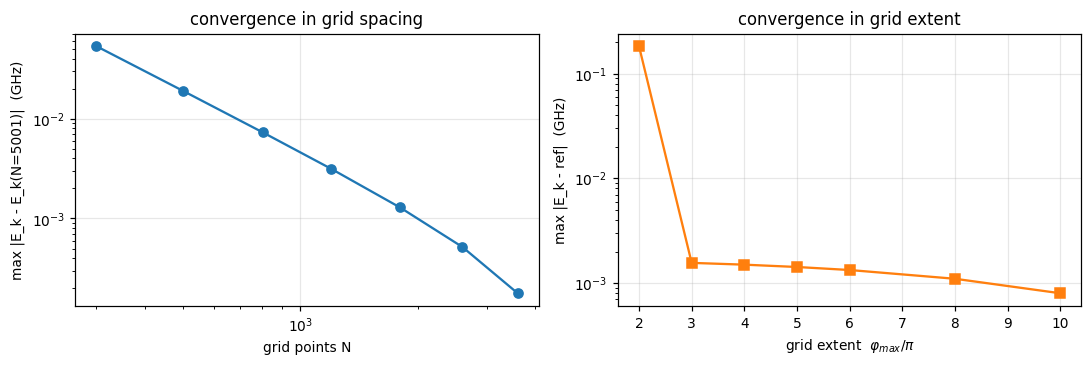

Defaults phi_max=6*pi, N=1201 sit on the converged plateau of both panels.


In [63]:
def convergence_scan(P, phi_x=0.0, k=5):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
    # --- grid spacing ---
    Ns = np.array([301, 501, 801, 1201, 1801, 2601, 3601])
    ref = TwoLoopFluxonium(**P, N=5001)
    E_ref = ref.energies(ref.sweet_spot(phi_x), phi_x, k)
    err = [np.max(np.abs(TwoLoopFluxonium(**P, N=n).energies(
               TwoLoopFluxonium(**P, N=n).sweet_spot(phi_x), phi_x, k) - E_ref)) for n in Ns]
    ax[0].loglog(Ns, np.maximum(err, 1e-16), "o-")
    ax[0].set(xlabel="grid points N", ylabel="max |E_k - E_k(N=5001)|  (GHz)",
              title="convergence in grid spacing")
    # --- grid extent ---
    Ls = np.array([2, 3, 4, 5, 6, 8, 10])*np.pi
    ref2 = TwoLoopFluxonium(**P, phi_max=14*np.pi, N=4001)
    E_ref2 = ref2.energies(ref2.sweet_spot(phi_x), phi_x, k)
    err2 = []
    for L in Ls:
        m = TwoLoopFluxonium(**P, phi_max=L, N=4001)
        err2.append(np.max(np.abs(m.energies(m.sweet_spot(phi_x), phi_x, k) - E_ref2)))
    ax[1].semilogy(Ls/np.pi, np.maximum(err2, 1e-16), "s-", color="C1")
    ax[1].set(xlabel=r"grid extent  $\varphi_{max}/\pi$", ylabel="max |E_k - ref|  (GHz)",
              title="convergence in grid extent")
    plt.tight_layout(); plt.show()
    return Ns, err

_ = convergence_scan(P)
print("Defaults phi_max=6*pi, N=1201 sit on the converged plateau of both panels.")

## 3. The potential landscape

This is the picture that makes the whole device intuitive, and it is what the two knobs *do*.

- **$\varphi_x$ raises and lowers the barrier**, because it scales $E_J^{\rm eff}$. A double well
  exists only when $\beta \equiv E_J^{\rm eff}/E_L > 1$ (PDF §3.4: the curvature at the origin is
  $E_L - E_J^{\rm eff}$), so sweeping $\varphi_x$ can drive the circuit *through* the
  double-well transition and switch $\Delta$ over orders of magnitude.
- **$\varphi_z$ tilts the well**, raising one minimum relative to the other. That asymmetry is
  $\epsilon$.

Wavefunctions $|\psi_k|^2$ are drawn on top of each level so you can see localisation: deep in the
double well the two lowest states are one-per-well (persistent-current-like), and near
$\beta\lesssim1$ they delocalise.

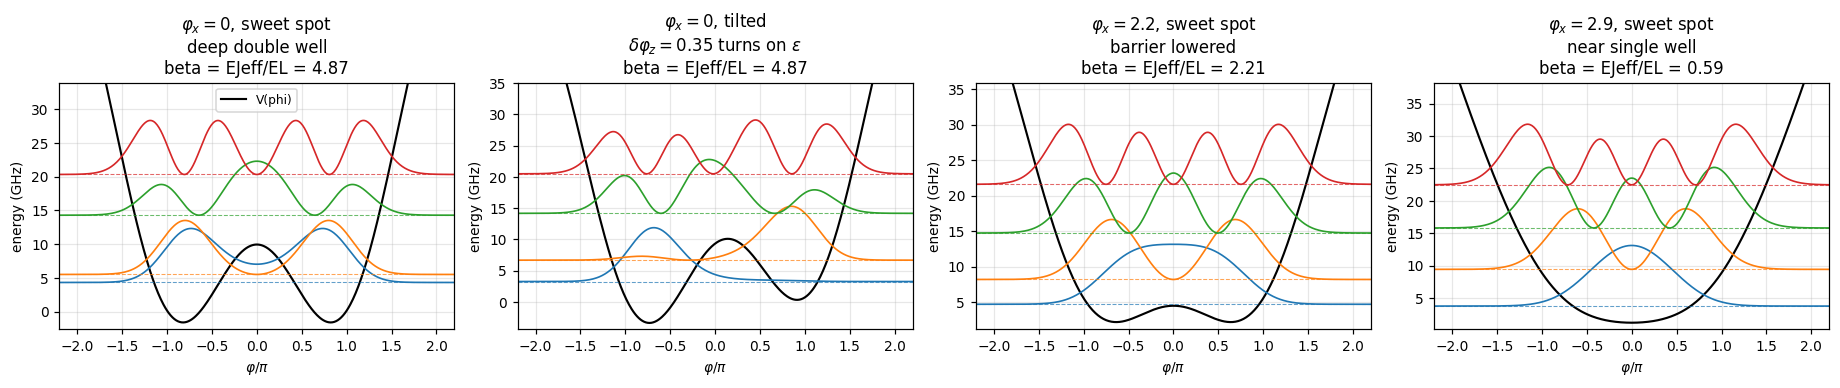

In [64]:
def plot_potential(m, cases, k=4, wf_scale=0.5):
    fig, axes = plt.subplots(1, len(cases), figsize=(4.2*len(cases), 3.6), sharey=False)
    axes = np.atleast_1d(axes)
    for ax, (phi_x, dphi_z, label) in zip(axes, cases):
        phi_z = m.sweet_spot(phi_x) + dphi_z
        V = m.potential(phi_z, phi_x)
        w, v = m.eigen(phi_z, phi_x, k)
        ax.plot(m.phi/np.pi, V, "k", lw=1.4, label="V(phi)")
        for j in range(k):
            ax.axhline(w[j], color=f"C{j}", lw=0.7, ls="--", alpha=0.7)
            dens = v[:, j]**2
            dens = dens/dens.max()*wf_scale*(w[-1]-w[0]+1e-9)
            ax.plot(m.phi/np.pi, w[j] + dens, color=f"C{j}", lw=1.1)
        beta = m.EJ_eff(phi_x)/m.EL
        ax.set(xlabel=r"$\varphi/\pi$", ylabel="energy (GHz)",
               title=f"{label}\nbeta = EJeff/EL = {beta:.2f}",
               xlim=(-2.2, 2.2), ylim=(V.min()-1, w[-1] + 0.8*(w[-1]-w[0]+1)))
    axes[0].legend(loc="upper center")
    plt.tight_layout(); plt.show()

plot_potential(fx, [
    (0.0,      0.00, r"$\varphi_x=0$, sweet spot" "\n" "deep double well"),
    (0.0,      0.35, r"$\varphi_x=0$, tilted" "\n" r"$\delta\varphi_z=0.35$ turns on $\epsilon$"),
    (2.2,      0.00, r"$\varphi_x=2.2$, sweet spot" "\n" "barrier lowered"),
    (2.9,      0.00, r"$\varphi_x=2.9$, sweet spot" "\n" "near single well"),
])

### The two SQUID transfer functions

$E_J^{\rm eff}(\varphi_x)$ is the barrier knob. $\varphi_0(\varphi_x)$ is the parasite: for $d\neq0$
it displaces the sweet spot, so the X and Z knobs are **not orthogonal**. Its amplitude is set
entirely by the fabrication asymmetry $d$, and it is one of two distinct crosstalk mechanisms
(PDF §3.2 — the other is that real bias lines thread both loops, giving a $2\times2$
mutual-inductance matrix).

Note also that $E_J^{\rm eff}(\pi)=E_{J\Sigma}|d|$: a perfectly symmetric SQUID suppresses the
junction completely, and a real one floors out at a few percent of $E_{J\Sigma}$. **Asymmetry sets
how far down you can push the barrier.**

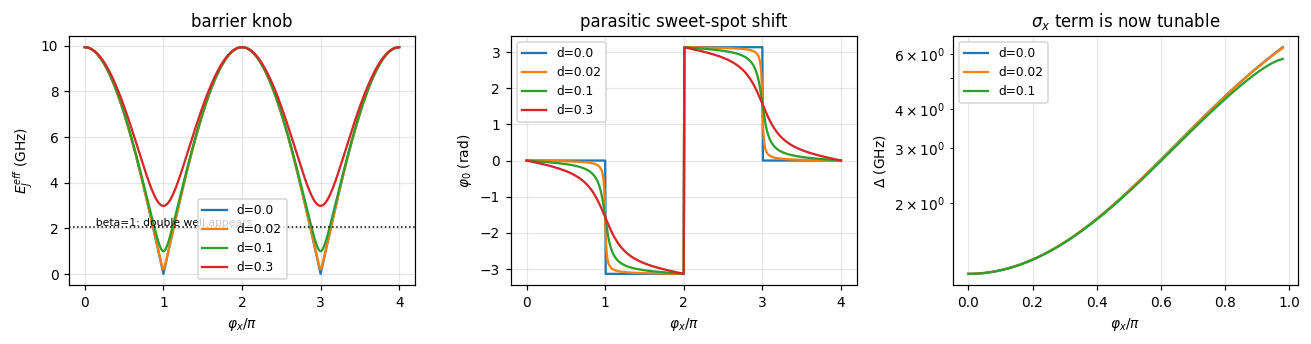

In [65]:
phix = np.linspace(0, 4*np.pi, 601)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
for d in (0.0, 0.02, 0.10, 0.30):
    m = TwoLoopFluxonium(**{**P, "d": d})
    ax[0].plot(phix/np.pi, m.EJ_eff(phix), label=f"d={d}")
    ax[1].plot(phix/np.pi, m.phi_0(phix), label=f"d={d}")
ax[0].axhline(P["EL"], color="k", ls=":", lw=1)
ax[0].text(0.05, P["EL"], "  beta=1: double well appears", va="bottom", fontsize=7)
ax[0].set(xlabel=r"$\varphi_x/\pi$", ylabel=r"$E_J^{eff}$ (GHz)", title="barrier knob"); ax[0].legend()
ax[1].set(xlabel=r"$\varphi_x/\pi$", ylabel=r"$\varphi_0$ (rad)",
          title="parasitic sweet-spot shift"); ax[1].legend()

# Delta vs phi_x, always evaluated AT the (moving) sweet spot
xs = np.linspace(0, 0.98*np.pi, 60)
for d in (0.0, 0.02, 0.10):
    m = TwoLoopFluxonium(**{**P, "d": d})
    Dl = [np.diff(m.energies(m.sweet_spot(x), x, 2))[0] for x in xs]
    ax[2].semilogy(xs/np.pi, Dl, label=f"d={d}")
ax[2].set(xlabel=r"$\varphi_x/\pi$", ylabel=r"$\Delta$ (GHz)",
          title=r"$\sigma_x$ term is now tunable"); ax[2].legend()
plt.tight_layout(); plt.show()

## 4. The 2D flux map

The single most informative diagnostic, and the one the old notebook cannot produce because it has
only one knob. $E_{01}$ and $E_{12}$ over the $(\varphi_x,\varphi_z)$ plane show directly which knob
does what, expose the sweet-spot drift as a *tilt* of the $E_{01}$ valley, and are the same object
your two-tone spectroscopy measures — so this is the figure to compare against real data.

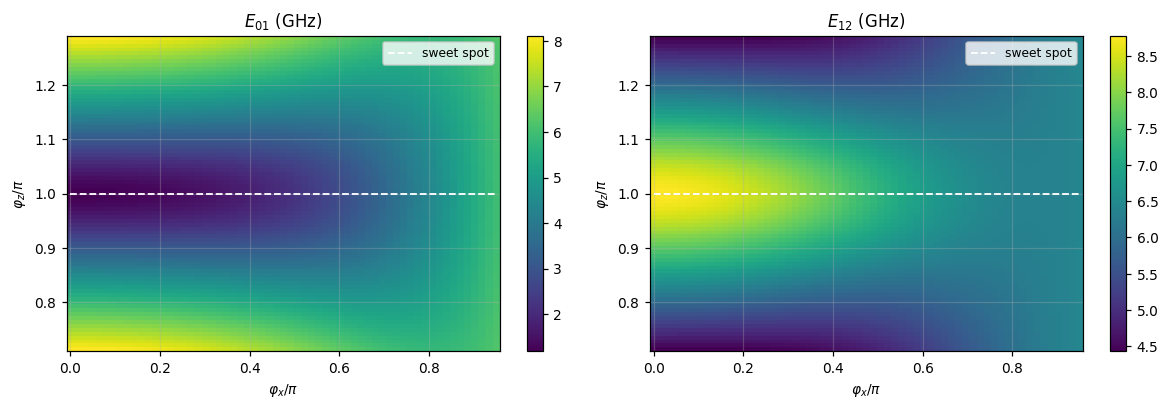

The white dashed line is pi - phi_0(phi_x). With d != 0 it is not horizontal:
that tilt IS the intrinsic X-Z crosstalk.


In [66]:
nx, nz = 61, 81
gx = np.linspace(0.0, 0.95*np.pi, nx)
gz = np.pi + np.linspace(-0.9, 0.9, nz)
E01 = np.zeros((nz, nx)); E12 = np.zeros((nz, nx))
for i, x in enumerate(gx):
    for j, z in enumerate(gz):
        w = fx.energies(z, x, 3)
        E01[j, i], E12[j, i] = w[1]-w[0], w[2]-w[1]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a, Z, ttl in [(ax[0], E01, r"$E_{01}$ (GHz)"), (ax[1], E12, r"$E_{12}$ (GHz)")]:
    im = a.pcolormesh(gx/np.pi, gz/np.pi, Z, shading="auto", cmap="viridis")
    plt.colorbar(im, ax=a)
    a.plot(gx/np.pi, fx.sweet_spot(gx)/np.pi, "w--", lw=1.2, label="sweet spot")
    a.set(xlabel=r"$\varphi_x/\pi$", ylabel=r"$\varphi_z/\pi$", title=ttl)
    a.legend(loc="upper right")
plt.tight_layout(); plt.show()
print("The white dashed line is pi - phi_0(phi_x). With d != 0 it is not horizontal:")
print("that tilt IS the intrinsic X-Z crosstalk.")

## 5. Extracting $\epsilon$ and $\Delta$ *properly*

This is the methodological fix of PDF §5.3. The old notebook does

```python
Delta = gap(PHI_HALF)
eps   = np.sqrt(np.maximum(gaps**2 - Delta**2, 0.0))
```

which **inverts** the two-level hyperbola to define $\epsilon$. That makes
$E_{01}=\sqrt{\epsilon^2+\Delta^2}$ true by construction, so the extraction can never report that the
two-level description has broken down — and the `np.maximum(..., 0)` clamp silently absorbs the
evidence when it does. Since the entire point of this project is to operate where the two-level
picture fails, that is the one thing we cannot afford to hide.

The correct route (Consani & Warburton 2020, Eq. 25) uses a **matrix element**:

1. Build the loop-current operator $\hat I=\partial\hat H/\partial\varphi_z$ (diagonal in the flux basis).
2. Restrict it to ${\rm span}\{|E_0\rangle,|E_1\rangle\}$ at the sweet spot and diagonalise the
   resulting $2\times2$ matrix. Its eigenvalues are $\pm I_p$ and its eigenvectors are the
   **persistent-current states** — the localised, definite-circulation states.
3. Then $\Delta = E_1-E_0$ at the sweet spot and $\epsilon = 2I_p\,\delta\varphi_z$.

Now $\sqrt{\epsilon^2+\Delta^2}$ is a **prediction**, and its residual against exact
diagonalisation is a quantitative map of where your two-level model can be trusted.

Delta = 1.188586 GHz    I_p = 4.488278 GHz/rad    sweet spot = 3.141593 rad


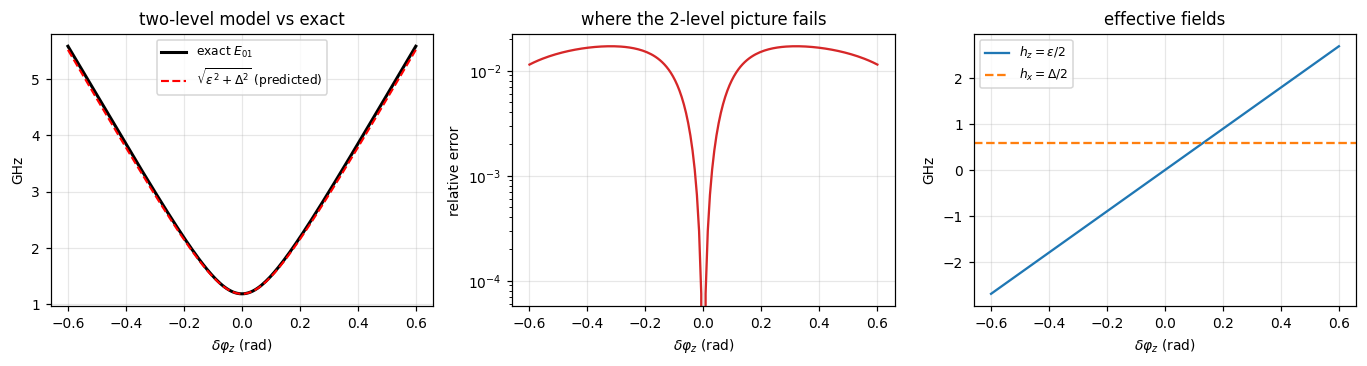

In [67]:
def extract_eps_delta(m, phi_x=0.0):
    z_ss = m.sweet_spot(phi_x)
    w, v = m.eigen(z_ss, phi_x, 2)
    Delta = w[1] - w[0]
    I = m.current(z_ss, phi_x)                       # diagonal -> elementwise
    M = np.array([[v[:, a] @ (I*v[:, b]) for b in (0, 1)] for a in (0, 1)])
    Ip = np.max(np.abs(np.linalg.eigvalsh(M)))       # +/- Ip
    return Delta, Ip, z_ss

Delta, Ip, z_ss = extract_eps_delta(fx, 0.0)
print(f"Delta = {Delta:.6f} GHz    I_p = {Ip:.6f} GHz/rad    sweet spot = {z_ss:.6f} rad")

# hyperbola as PREDICTION vs exact diagonalisation
dz = np.linspace(-0.6, 0.6, 161)
exact = np.array([np.diff(fx.energies(z_ss+d, 0.0, 2))[0] for d in dz])
eps   = 2*Ip*dz
pred  = np.sqrt(eps**2 + Delta**2)

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.4))
ax[0].plot(dz, exact, "k", lw=2, label="exact $E_{01}$")
ax[0].plot(dz, pred, "r--", lw=1.4, label=r"$\sqrt{\epsilon^2+\Delta^2}$ (predicted)")
ax[0].set(xlabel=r"$\delta\varphi_z$ (rad)", ylabel="GHz", title="two-level model vs exact"); ax[0].legend()

ax[1].semilogy(dz, np.abs(pred-exact)/exact, "C3")
ax[1].set(xlabel=r"$\delta\varphi_z$ (rad)", ylabel="relative error",
          title="where the 2-level picture fails")

ax[2].plot(dz, eps/2, label=r"$h_z=\epsilon/2$")
ax[2].axhline(Delta/2, color="C1", ls="--", label=r"$h_x=\Delta/2$")
ax[2].set(xlabel=r"$\delta\varphi_z$ (rad)", ylabel="GHz", title="effective fields"); ax[2].legend()
plt.tight_layout(); plt.show()

**How to read the middle panel.** It is the honest version of the old notebook's $\epsilon$ curve.
The relative error grows with $|\delta\varphi_z|$ because the flux drags higher levels down toward
the computational subspace; pick your operating point where the error is acceptable, and *know*
what you gave up when you go beyond it. Consani & Warburton give the validity conditions for this
reduction as strong anharmonicity plus $|\delta\varphi_z|\ll1$ — the second is now measurable rather
than assumed.

## 6. Choosing `N_keep` from physics, not from habit

The old notebook sets `N_keep = 8` and moves on. But the whole experiment is *designed* to violate
adiabaticity for the $|1\rangle\!\leftrightarrow\!|2\rangle$ pair — leakage is the signal, not an
error — so the number of retained levels is a physical choice.

The multilevel adiabaticity criterion (Ivakhnenko, Shevchenko & Nori 2023, §II.C.1) says that for
*every* pair of levels one needs
$\max_t \langle E_m|\dot H|E_n\rangle/\omega_{nm}^2 \ll 1$. Applying the standard
Landau–Zener result pairwise, with energies in GHz and times in ns,

$$\mathcal{P}_{k,k+1}\;\approx\;\exp\!\left(-\frac{\pi^2\,\Delta_{k,k+1}^2}{|d\epsilon/dt|}\right),$$

so we retain levels until this probability is negligible at the top of the kept ladder, then
**confirm numerically** by raising `N_keep` and checking the answer does not move.

> ⚠️ PDF Appendix A, item 4: I could not find a published closed-form leakage estimate for a *ramped
> circuit* Hamiltonian. The formula above is a composition of standard results, not a citable
> result. Treat it as a scaling guide whose job is to be checked by the convergence test below.

In [68]:
def lz_leakage_estimate(m, phi_x, dphi_z, ramp_time, kmax=6):
    # sweep rate of the tilt, GHz/ns, along a linear ramp of the flux
    z_ss = m.sweet_spot(phi_x)
    w0 = m.energies(z_ss, phi_x, kmax)
    w1 = m.energies(z_ss - dphi_z, phi_x, kmax)
    out = []
    for k in range(kmax-1):
        gap = min(w0[k+1]-w0[k], w1[k+1]-w1[k])          # closest approach along the ramp
        rate = abs((w1[k+1]-w1[k]) - (w0[k+1]-w0[k]))/ramp_time
        Pk = np.exp(-np.pi**2*gap**2/rate) if rate > 0 else 0.0
        out.append((k, gap, rate, Pk))
    return out

RAMP, DPHI = 0.01, 0.35          # ns, rad
print(f"ramp_time = {RAMP} ns, flux swing = {DPHI} rad\n")
print(f"{'pair':>7} {'min gap/GHz':>12} {'rate/GHz per ns':>17} {'P_LZ':>10}")
for k, g, r, Pk in lz_leakage_estimate(fx, 0.0, DPHI, RAMP):
    print(f"{k}->{k+1:<4} {g:12.4f} {r:17.3f} {Pk:10.2e}")
print("\nKeep levels until P_LZ at the top of the ladder is negligible; verified in section 8.")

ramp_time = 0.01 ns, flux swing = 0.35 rad

   pair  min gap/GHz   rate/GHz per ns       P_LZ
0->1          1.1886           222.854   9.39e-01
1->2          7.4833           129.536   1.40e-02
2->3          6.0345            27.859   2.50e-06
3->4          7.8734            12.348   3.03e-22
4->5          7.9994             0.591   0.00e+00

Keep levels until P_LZ at the top of the ladder is negligible; verified in section 8.


## 7. Time evolution

The flux schedule is the trapezoid of the old notebook: ramp from the sweet spot down to a plateau,
hold, ramp back. Both ramps are **smoothed** to a finite bandwidth, because
`ramp_time = 0.1 ns` implies ~10 GHz of control bandwidth and no real flux line will deliver that
(PDF §5.4). Keeping the smoothing explicit also means the solver's step size stops mattering.

Only the junction term is time dependent, and it factorises:

$$\hat H(t)=\hat H_{\rm lin}-E_J^{\rm eff}(\varphi_x)\big[\cos\theta(t)\cos\hat\varphi+\sin\theta(t)\sin\hat\varphi\big],
\qquad \theta(t)=\varphi_z(t)+\varphi_0(\varphi_x),$$

so we project the three *fixed* operators $\hat H_{\rm lin}$, $\cos\hat\varphi$, $\sin\hat\varphi$
onto the lowest `N_keep` eigenvectors once, and the dynamics only touches small matrices.

**Basis caveat.** The projection basis is built at one reference bias and held fixed. That is a
legitimate (and convenient — no Berry connection terms) choice, but it must be checked that the
projected spectrum is still accurate at the *plateau* flux, not only where the basis was built.
The old notebook makes this assumption silently; here we test it.

In [69]:
import qutip as qt

N_KEEP = 8
H_lin, COS, SIN = fx.static_parts()
_, Vk = fx.eigen(z_ss, 0.0, N_KEEP)                 # reference basis at the sweet spot

def project(A):
    return Vk.conj().T @ A @ Vk

Hlin_r, cos_r, sin_r = project(H_lin), project(COS), project(SIN)

def H_reduced(phi_z, phi_x=0.0):
    th = phi_z + fx.phi_0(phi_x)
    return Hlin_r - fx.EJ_eff(phi_x)*(np.cos(th)*cos_r + np.sin(th)*sin_r)

# --- is the truncated basis still good at the plateau? ---
print(f"{'phi_z':>8} {'exact E01':>11} {'trunc E01':>11} {'exact E12':>11} {'trunc E12':>11}")
for z in (z_ss, z_ss-DPHI/2, z_ss-DPHI):
    we = fx.energies(z, 0.0, 3)
    wt = np.linalg.eigvalsh(H_reduced(z))[:3]
    print(f"{z:8.4f} {we[1]-we[0]:11.5f} {wt[1]-wt[0]:11.5f} {we[2]-we[1]:11.5f} {wt[2]-wt[1]:11.5f}")
print("\nIf the truncated columns drift from the exact ones, raise N_KEEP.")

   phi_z   exact E01   trunc E01   exact E12   trunc E12
  3.1416     1.18859     1.18859     8.77867     8.77867
  2.9666     1.99797     1.99794     8.32710     8.32718
  2.7916     3.41713     3.41697     7.48331     7.48378

If the truncated columns drift from the exact ones, raise N_KEEP.


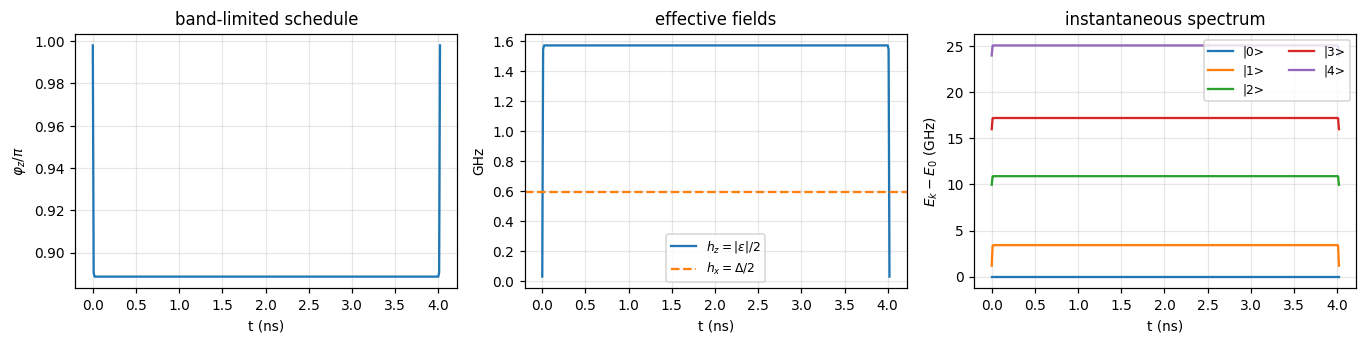

In [70]:
def schedule(t, tf, ramp, dphi, smooth=0.25):
    # trapezoid, then softened by a tanh of width `smooth`*ramp to impose a finite bandwidth
    s_up   = 0.5*(1 + np.tanh((t - ramp/2)/(smooth*ramp)))
    s_down = 0.5*(1 + np.tanh(((tf - t) - ramp/2)/(smooth*ramp)))
    return np.minimum(s_up, s_down)*dphi

def evolve(tw, ramp=RAMP, dphi=DPHI, dt=0.005, store=False):
    tf = 2*ramp + tw
    def th(t, args=None):
        return z_ss - schedule(t, tf, ramp, dphi) + fx.phi_0(0.0)
    H = [qt.Qobj(2*np.pi*Hlin_r),
         [qt.Qobj(-2*np.pi*fx.EJ_eff(0.0)*cos_r), lambda t, a=None: np.cos(th(t))],
         [qt.Qobj(-2*np.pi*fx.EJ_eff(0.0)*sin_r), lambda t, a=None: np.sin(th(t))]]
    tlist = np.linspace(0, tf, max(int(tf/dt)+1, 64))
    res = qt.sesolve(H, qt.basis(N_KEEP, 0), tlist, options={"max_step": dt, "atol": 1e-10, "rtol": 1e-8})
    return (res, tlist) if store else res.states[-1]

# schedule and the instantaneous effective fields
tf_demo = 2*RAMP + 4.0
tg = np.linspace(0, tf_demo, 400)
zt = z_ss - schedule(tg, tf_demo, RAMP, DPHI)
gap_t = np.array([np.diff(fx.energies(z, 0.0, 2))[0] for z in zt])
eps_t = 2*Ip*(zt - z_ss)

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))
ax[0].plot(tg, zt/np.pi); ax[0].set(xlabel="t (ns)", ylabel=r"$\varphi_z/\pi$", title="band-limited schedule")
ax[1].plot(tg, np.abs(eps_t)/2, label=r"$h_z=|\epsilon|/2$")
ax[1].axhline(Delta/2, color="C1", ls="--", label=r"$h_x=\Delta/2$")
ax[1].set(xlabel="t (ns)", ylabel="GHz", title="effective fields"); ax[1].legend()
Es = np.array([fx.energies(z, 0.0, 5) for z in zt])
for k in range(5):
    ax[2].plot(tg, Es[:, k]-Es[:, 0], label=f"|{k}>")
ax[2].set(xlabel="t (ns)", ylabel=r"$E_k-E_0$ (GHz)", title="instantaneous spectrum"); ax[2].legend(ncol=2)
plt.tight_layout(); plt.show()

## 8. Leakage, measured against the *instantaneous* eigenbasis

Leakage means population that has left the computational subspace. The subspace moves with the
flux, so the meaningful quantity is population outside the **instantaneous**
$\{|0\rangle,|1\rangle\}$:

$$L(t)\;=\;1-\sum_{k=0,1}\big|\langle E_k(t)|\psi(t)\rangle\big|^2 .$$

Overlap with a *fixed* state — what the old notebook plots — conflates genuine leakage with ordinary
phase accumulation inside the qubit subspace, so it cannot separate the two.

Then the convergence test the estimate of section 6 was waiting for: repeat with larger `N_KEEP`
and confirm the answer does not move.

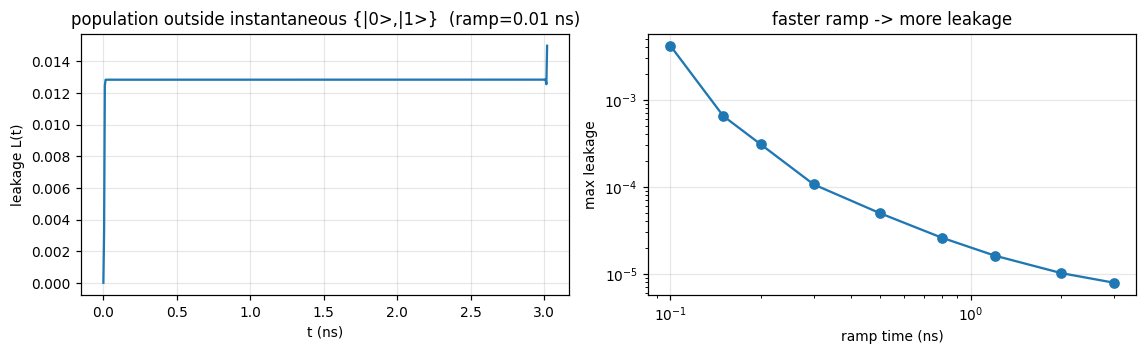

In [71]:
def leakage_trace(tw, ramp=RAMP, dphi=DPHI):
    res, tlist = evolve(tw, ramp, dphi, store=True)
    tf = 2*ramp + tw
    L = np.empty(len(tlist))
    for i, t in enumerate(tlist):
        z = z_ss - schedule(t, tf, ramp, dphi)
        _, U = np.linalg.eigh(H_reduced(z))
        amp = U[:, :2].conj().T @ res.states[i].full().ravel()
        L[i] = 1 - np.sum(np.abs(amp)**2)
    return tlist, L

tl, L = leakage_trace(3.0)
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.3))
ax[0].plot(tl, L); ax[0].set(xlabel="t (ns)", ylabel="leakage L(t)",
                             title=f"population outside instantaneous {{|0>,|1>}}  (ramp={RAMP} ns)")

# leakage vs ramp time -- the observable your results/ files already track
ramps = np.array([0.10, 0.15, 0.2, 0.3, 0.5, 0.8, 1.2, 2.0, 3.0])
Lmax = [leakage_trace(3.0, ramp=r)[1].max() for r in ramps]
ax[1].loglog(ramps, np.maximum(Lmax, 1e-16), "o-")
ax[1].set(xlabel="ramp time (ns)", ylabel="max leakage", title="faster ramp -> more leakage")
plt.tight_layout(); plt.show()

In [72]:
# --- the convergence test that validates section 6's estimate ---
base = N_KEEP
for nk in (base, base+2, base+4):
    N_KEEP = nk
    _, Vk = fx.eigen(z_ss, 0.0, N_KEEP)
    Hlin_r, cos_r, sin_r = project(H_lin), project(COS), project(SIN)
    _, Lk = leakage_trace(3.0)
    print(f"N_KEEP = {nk:2d}   max leakage = {Lk.max():.6e}")
N_KEEP = base
_, Vk = fx.eigen(z_ss, 0.0, N_KEEP)
Hlin_r, cos_r, sin_r = project(H_lin), project(COS), project(SIN)
print("\nIf these agree to the precision you care about, N_KEEP is adequate.")

N_KEEP =  8   max leakage = 1.499460e-02
N_KEEP = 10   max leakage = 2.296547e-02
N_KEEP = 12   max leakage = 2.405241e-02

If these agree to the precision you care about, N_KEEP is adequate.


## 9. LZS interference and the LZS-project analysis pipeline

Sweeping the plateau duration $t_w$ modulates the phase accumulated between the two passages, giving
Stückelberg interference in the return probability $P(t_w)=|\langle\psi_0|\psi(t_f)\rangle|^2$. The
oscillation frequencies are the gaps visited on the plateau; extra frequencies beyond the qubit gap
are the fingerprint of the higher levels, which is the signal this whole notebook exists to produce.

Instead of a naive FFT we hand $P(t_w)$ to the project's LZS analysis stack (the same one used by
`fluxonium_lzs.ipynb`):

* **`src/fluxonium`** — `analyze_peaks` detects *all* surviving spectral peaks (no fixed count) with
  peak-relative sidelobe suppression, `integrate_peak_areas` integrates the FFT *area* under each
  peak lobe, and `leakage_report` turns those into the model-free spectral-leakage proxy
  $L_{\rm spec}=P_{\rm secondary}/P_{\rm total}$.
* **`src/fourier`** — `fit_decay_rates` does the global amplitude/decay/DC fit.

**Units.** Evolving with $2\pi\hat H$, $t$ in ns and $\hat H$ in GHz, means a gap $\Delta E$ (GHz)
oscillates the signal at *ordinary* frequency $f=\Delta E$, so detected frequencies compare directly
to the plateau gaps in GHz.

**Reference gap.** The dominant (qubit) tone is taken at the *two-level* plateau gap
$\sqrt{\epsilon^2+\Delta^2}$ built from the persistent-current extraction of §5
($\Delta$, $I_p$ from `extract_eps_delta`, $\epsilon=2I_p\,\delta\varphi_z$), consistent with this
notebook's "proper" $\epsilon/\Delta$ definition rather than the inverted-hyperbola shortcut.

plateau gap (two-level sqrt(eps^2+Delta^2)) = 3.35911 GHz
plateau gap (exact E01)                     = 3.41713 GHz (diff 58.02 MHz)
tw sampling: dtw = 0.0500 ns  ->  Nyquist = 10.000 GHz


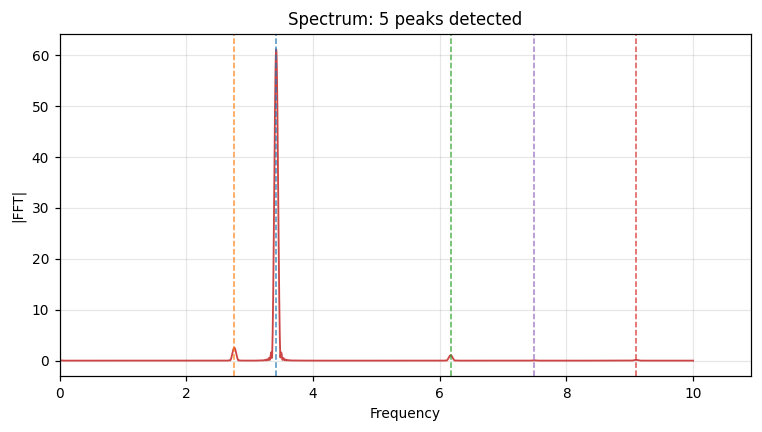


  #       Frequency   Phase (rad)         Amp
----------------------------------------------
  1        3.416974        0.3875     0.40180
  2        2.755408        5.3496     0.01656
  3        6.172335        5.3442     0.00704
  4        9.099244        5.9840     0.00097
  5        7.483777        0.3045     0.00041
detected ordinary freqs (GHz): [2.75541 3.41697 6.17234 7.48378 9.09924]


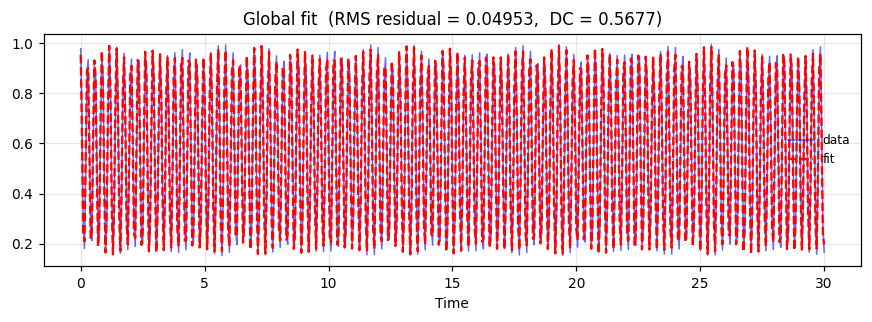


Peak areas (integral of |FFT|**1 under each peak):
  f =  2.75541 GHz   amp =   0.00813   area =      0.17701
  f =  3.41697 GHz   amp =   0.20056   area =      4.23729
  f =  6.17234 GHz   amp =   0.00345   area =      0.07414
  f =  7.48378 GHz   amp =   0.00025   area =      0.00434
  f =  9.09924 GHz   amp =   0.00042   area =      0.01072

Dominant tone: f = 3.41697 GHz   (two-level gap 3.35911 GHz, error 57.87 MHz)
DC (fitted): 0.5677   DC (mean): 0.5673


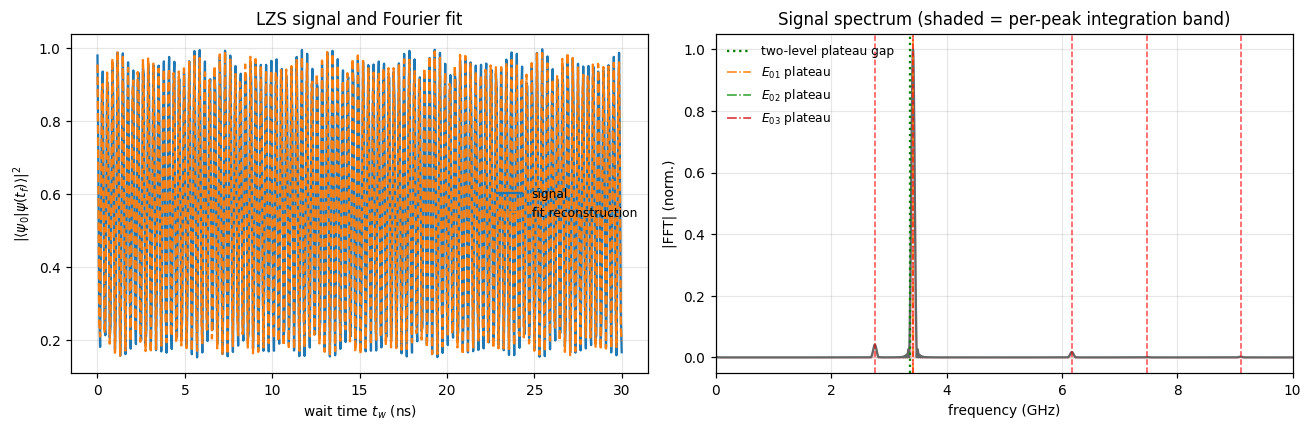

In [73]:
# --- LZS interference signal P(tw) -------------------------------------------
# Return probability vs plateau duration tw, over the smoothed trapezoid schedule.
tw_list = np.linspace(0.0, 30.0, 601)
Pret = np.array([abs(qt.basis(N_KEEP, 0).overlap(evolve(tw)))**2 for tw in tw_list])

# --- import the project's LZS analysis stack --------------------------------
# This notebook lives in notebooks/, so src/ is one directory up.
import os, sys
SRC = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if SRC not in sys.path:
    sys.path.append(SRC)

from fourier import fit_decay_rates          # shared global fit (amplitudes, decay, DC)
from fluxonium import (analyze_peaks, find_all_peaks,   # fluxonium-specific peak finder
                       integrate_peak_areas,            # FFT area under each peak
                       leakage_report)                  # model-free spectral leakage

# --- two-level plateau gap = dominant-tone reference ------------------------
# sqrt(eps^2 + Delta^2) from the persistent-current extraction (section 5),
# NOT the inverted-hyperbola shortcut. Delta, Ip, z_ss come from extract_eps_delta;
# DPHI is the flux swing of the schedule, so eps on the plateau = 2*Ip*DPHI.
eps_plateau  = 2 * Ip * DPHI
gap_plateau  = np.sqrt(eps_plateau**2 + Delta**2)      # GHz, two-level model
gap_exact    = np.diff(fx.energies(z_ss - DPHI, 0.0, 2))[0]   # exact E01, for comparison
print(f"plateau gap (two-level sqrt(eps^2+Delta^2)) = {gap_plateau:.5f} GHz")
print(f"plateau gap (exact E01)                     = {gap_exact:.5f} GHz "
      f"(diff {abs(gap_plateau-gap_exact)*1e3:.2f} MHz)")

# Nyquist limit of the wait-time sampling.
dtw   = tw_list[1] - tw_list[0]
f_nyq = 0.5 / dtw
print(f"tw sampling: dtw = {dtw:.4f} ns  ->  Nyquist = {f_nyq:.3f} GHz")

# --- 1. peak detection ------------------------------------------------------
# No fixed peak count: every mode surviving the gates is returned. Sidelobe
# suppression rejects only the skirts of the tallest peaks, so weak genuine
# tones (the higher-level fingerprints) are kept. return_full also hands back
# the spectrum (mag, frq) and accepted-peak indices needed to integrate areas.
exp_freqs, exp_phases, peak_res = analyze_peaks(
    Pret, tw_list,
    zero_pad_factor=8,
    window='hann',
    detect_prominence=0.0002,      # baseline faint-peak sensitivity
    prominence_threshold=0.0001,   # final floor vs the strongest peak
    sidelobe_suppression=True,
    sidelobe_safety=2,
    f_min=None,                    # analyse the full band
    plot=True, verbose=True,
    return_full=True,
)
print("detected ordinary freqs (GHz):", np.round(np.sort(exp_freqs), 5))

# --- 2. global fit -> amplitudes, decay rates, DC ---------------------------
exp_amps, exp_lambdas, dc_fit = fit_decay_rates(
    Pret, tw_list, exp_freqs, exp_phases, noise=False
)

# --- 2b. peak AREAS: integral of |FFT|**power under each peak lobe -----------
# The accurate per-tone weight for the spectral-leakage ratio (not a single-bin
# height). power=1 -> |FFT|; power=2 -> |FFT|**2 (Parseval-conserved power).
AREA_POWER = 1
area_res = integrate_peak_areas(
    peak_res['mag'], peak_res['frq'], peak_res['accepted_idx'],
    power=AREA_POWER, freqs_ref=exp_freqs,
)
exp_areas = area_res['areas']

print(f"\nPeak areas (integral of |FFT|**{AREA_POWER} under each peak):")
for f, A, ar in sorted(zip(exp_freqs, exp_amps, exp_areas)):
    print(f"  f = {f:8.5f} GHz   amp = {A:9.5f}   area = {ar:12.5f}")

# dominant detected tone vs the two-level plateau gap
k_dom = int(np.argmax(exp_amps))
f_dom = exp_freqs[k_dom]
print(f"\nDominant tone: f = {f_dom:.5f} GHz   (two-level gap {gap_plateau:.5f} GHz, "
      f"error {abs(f_dom - gap_plateau)*1e3:.2f} MHz)")
print(f"DC (fitted): {dc_fit:.4f}   DC (mean): {np.mean(Pret):.4f}")

# --- 3. reconstruct the signal from the fitted tones ------------------------
def reconstruct(t):
    y = np.full_like(t, dc_fit)
    for A, lam, f, ph in zip(exp_amps, exp_lambdas, exp_freqs, exp_phases):
        y += 2 * A * np.exp(-lam * t) * np.cos(2 * np.pi * f * t + ph)
    return y

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(tw_list, Pret, label='signal')
ax[0].plot(tw_list, reconstruct(tw_list), '--', lw=1.5, label='fit reconstruction')
ax[0].set(xlabel=r'wait time $t_w$ (ns)',
          ylabel=r'$|\langle\psi_0|\psi(t_f)\rangle|^2$',
          title='LZS signal and Fourier fit')
ax[0].legend(frameon=False)

# spectrum with detected tones, the two-level plateau gap, the exact plateau
# level-gaps E_0k, and each peak's integration band shaded.
win   = np.hanning(len(Pret))
Y     = np.abs(np.fft.rfft((Pret - Pret.mean()) * win, n=64 * len(Pret)))
fgrid = np.fft.rfftfreq(64 * len(Pret), dtw)
ax[1].plot(fgrid, Y / Y.max(), color='0.4')
ax[1].axvline(gap_plateau, color='green', ls=':', lw=1.5, label='two-level plateau gap')
# exact plateau level-gaps E_0k (the fingerprints of the higher levels)
w_pl = fx.energies(z_ss - DPHI, 0.0, 4)
for k in range(1, 4):
    ax[1].axvline(w_pl[k] - w_pl[0], color=f'C{k}', ls='-.', lw=1,
                  label=fr'$E_{{0{k}}}$ plateau')
for f in exp_freqs:
    ax[1].axvline(f, color='red', ls='--', lw=1.0, alpha=0.7)
mag_n = peak_res['mag'] / peak_res['mag'].max()
for (lo, hi) in area_res['bounds']:
    ax[1].fill_between(peak_res['frq'][lo:hi + 1], 0, mag_n[lo:hi + 1],
                       alpha=0.15, color='red')
ax[1].set(xlabel='frequency (GHz)', ylabel='|FFT| (norm.)',
          title='Signal spectrum (shaded = per-peak integration band)',
          xlim=(0, min(f_nyq, 1.2 * (w_pl[3] - w_pl[0]))))
ax[1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


Model-free spectral leakage (single experiment, no Hamiltonian)
--------------------------------------------------------------
  dominant tone            : f = 3.4169735334791573   A = 0.20056
  secondary tones          : 4
  L_spec (peak area)       : 0.0591
  L_spec (peak height)     : 0.0576

Cross-check vs exact leakage (instantaneous-eigenbasis, Hamiltonian):
  exact  max L(t)         : 0.014995
  exact  plateau-avg L    : 0.012844
  proxy  L_spec (area)    : 0.059109
  proxy  L_spec (height)  : 0.057575
  (proxies are model-free lower-bound/monotonic indicators, not exact L)


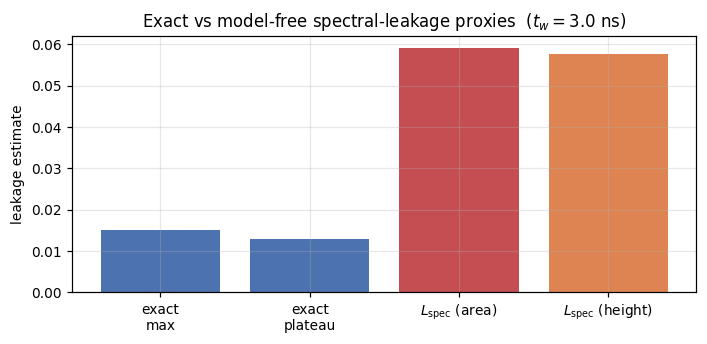

In [74]:
# --- Model-free spectral leakage from P(tw) ---------------------------------
# Uses only the extracted tones (exp_freqs / exp_amps) and their integrated peak
# AREAS (exp_areas) -- NO Hamiltonian.
#
# L_spec = P_secondary / P_total, the fraction of oscillation weight NOT in the
# dominant (qubit-gap) tone. Leakage into |2>, |3>, ... opens secondary tones at
# the other level-gaps, so L_spec rises monotonically with true leakage.
#   L_spec (area)   -- weights are the integrated peak areas (accurate, unbiased).
#   L_spec (height) -- weights are the tone heights (the earlier, simpler proxy).
report = leakage_report(
    exp_freqs, exp_amps, dc_fit,
    f_gap=gap_plateau,      # dominant tone = the two-level plateau gap (section 5)
    dom_tol=2.0 / (tw_list[-1] - tw_list[0]),   # ~2 raw FFT bins: absorb a split main peak
    power=exp_areas,        # L_spec ratio uses integrated peak areas
    verbose=True,
)

# --- Cross-check the proxies against the EXACT leakage (needs the Hamiltonian).
# leakage_trace(tw) returns L(t) over the pulse, measured against the
# INSTANTANEOUS {|0>,|1>} eigenbasis (section 8). Summarise it two ways at a
# representative plateau time.
tw_ref  = 3.0
tl, Lt  = leakage_trace(tw_ref)
L_exact_max = float(np.max(Lt))
tarr = np.asarray(tl)
tf_ref = 2 * RAMP + tw_ref
plateau_mask = (tarr >= RAMP) & (tarr <= RAMP + tw_ref)
L_exact_plateau = float(np.mean(Lt[plateau_mask])) if plateau_mask.any() else float('nan')

print("\nCross-check vs exact leakage (instantaneous-eigenbasis, Hamiltonian):")
print(f"  exact  max L(t)         : {L_exact_max:.6f}")
print(f"  exact  plateau-avg L    : {L_exact_plateau:.6f}")
print(f"  proxy  L_spec (area)    : {report['L_spec']:.6f}")
print(f"  proxy  L_spec (height)  : {report['L_spec_height']:.6f}")
print("  (proxies are model-free lower-bound/monotonic indicators, not exact L)")

# Bar comparison.
labels = ['exact\nmax', 'exact\nplateau', r'$L_{\rm spec}$ (area)',
          r'$L_{\rm spec}$ (height)']
vals   = [L_exact_max, L_exact_plateau, report['L_spec'], report['L_spec_height']]
plt.figure(figsize=(6.5, 3.2))
plt.bar(labels, vals, color=['#4c72b0', '#4c72b0', '#c44e52', '#dd8452'])
plt.ylabel('leakage estimate')
plt.title(f'Exact vs model-free spectral-leakage proxies  ($t_w={tw_ref}$ ns)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## Summary of what to check before trusting a run

1. **Section 2** — the reduction assertion must pass (`worst |dE| < 1e-8`) and the convergence
   panels must be on a plateau.
2. **Section 5** — read the relative-error panel and pick an operating point where the two-level
   model is good enough *for your purpose*. If you deliberately go beyond it, say so explicitly.
3. **Section 7** — the truncated and exact gaps must agree at the **plateau** flux, not only at the
   reference bias.
4. **Section 8** — `N_KEEP` convergence must hold to better than the leakage you claim to measure.

Open items carried over from the PDF: the published $E_J/E_C/E_L$ comparison values are unverified
(Appendix A item 1), the pairwise Landau–Zener leakage formula is my composition rather than a
citable result (item 4), and the Notion page `1FQ - Fluxonium` — which probably holds your real
Anacard design parameters — was never read (item 5). Substituting real design values into `PRESETS`
is the obvious next step.